# **Tabular Deep Learning with Embeddings using Artificial Neural Networks (ANN)**

---

## **Project Objective**

The objective of this project is to develop a **Tabular Deep Learning System using Artificial Neural Networks (ANN) with Embeddings** to efficiently model structured data containing both categorical and numerical features.

Traditional machine learning models often struggle with high-cardinality categorical variables and complex feature interactions. This project focuses on leveraging **embedding layers** to transform categorical variables into dense vector representations, enabling the model to learn meaningful relationships between categories.

The system is designed to:

- Handle **mixed data types (categorical + numerical features)**  
- Learn **dense embeddings for categorical variables**  
- Capture **complex, non-linear feature interactions**  
- Improve performance over traditional encoding techniques (e.g., one-hot encoding)  

This project is highly applicable in:
- recommendation systems  
- customer analytics and segmentation  
- fraud detection and risk modeling  
- marketing and personalization systems  

---

## **Dataset Used**

This project utilizes structured tabular datasets containing both categorical and numerical features.

### **Dataset Sources**

- Kaggle tabular datasets  
- UCI structured datasets  
- enterprise-style datasets (if simulated in your notebook)  

### **Dataset Characteristics**

The dataset includes:

- **Categorical features**, such as:
  - user ID / product ID  
  - categories or segments  
  - location or demographic attributes  

- **Numerical features**, such as:
  - transaction amounts  
  - counts or frequencies  
  - continuous variables  

- Target variable:
  - classification or regression output (depending on use case)  

Key characteristics:
- high-cardinality categorical variables  
- mixed data types  
- complex feature interactions  

### **How Dataset is Used in the Project**

The dataset is processed through a structured pipeline:

- **Data preprocessing**
  - handling missing values  
  - separating categorical and numerical features  

- **Categorical encoding using embeddings**
  - mapping categories to integer indices  
  - learning dense vector representations  

- **Numerical feature scaling**
  - normalization or standardization  

- **Train-validation-test split**
  - ensures model generalization  

- **Model training**
  - ANN trained with embedding layers + dense layers  

The dataset enables the model to learn **rich representations of categorical variables**, improving predictive performance.

---

## **Project Summary**

This project presents a complete implementation of a **Tabular Deep Learning System using Artificial Neural Networks with Embeddings**, focusing on improving performance on structured datasets.

The workflow begins with preprocessing the dataset by separating categorical and numerical features. Categorical variables are transformed into integer indices and passed through embedding layers, while numerical features are scaled and directly fed into the model.

The core of the system is an **Artificial Neural Network with embedding layers**, which learns compact representations of categorical variables. The model learns patterns such as:
- relationships between different categories  
- interaction between categorical and numerical features  
- hidden dependencies across features  

The ANN architecture includes:
- embedding layers for categorical features  
- input layer for numerical features  
- concatenation layer combining all features  
- dense layers capturing complex interactions  
- output layer predicting target values  

A key strength of this project is the use of **embedding layers**, which:
- reduce dimensionality compared to one-hot encoding  
- capture semantic relationships between categories  
- improve scalability for large datasets  

Evaluation is performed using:
- classification metrics (accuracy, precision, recall, F1-score)  
- regression metrics (MAE, RMSE) depending on the task  

The system can be used in real-world applications to:
- improve prediction accuracy on tabular data  
- handle large-scale categorical features  
- enable personalized recommendations and analytics  

Overall, this project demonstrates modern deep learning techniques for structured data, showcasing the ability to build **scalable and high-performance tabular models**.

---

## **Key Highlights**

- Built a **Tabular Deep Learning system using ANN with Embeddings**, targeting modern ML applications.

- Addressed key challenge of **high-cardinality categorical features**.

- Utilized structured dataset with:
  - categorical variables  
  - numerical features  

- Implemented advanced **embedding-based encoding**, enabling:
  - dense representation learning  
  - dimensionality reduction  

- Developed a complete **data preprocessing pipeline**, including:
  - missing value handling  
  - feature separation  
  - scaling  

- Designed an **ANN architecture**, consisting of:
  - embedding layers  
  - dense layers  
  - feature concatenation  

- Captured **complex feature interactions**, including:
  - categorical–categorical relationships  
  - categorical–numerical interactions  

- Improved model efficiency by:
  - replacing one-hot encoding with embeddings  
  - reducing input dimensionality  

- Evaluated model performance using:
  - classification and/or regression metrics  

- Enabled **real-world applications**, including:
  - recommendation systems  
  - customer analytics  
  - fraud detection  

- Demonstrates strong expertise in:
  - **Artificial Neural Networks (ANN)**  
  - **embedding techniques**  
  - **tabular deep learning**

---


In [1]:
# ============================================================
# CELL 1 - IMPORT CORE LIBRARIES
# ============================================================

import os
import math
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


In [2]:
# ============================================================
# CELL 2 - IMPORT VISUALIZATION LIBRARIES
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


In [3]:
# ============================================================
# CELL 3 - IMPORT SCIKIT-LEARN UTILITIES
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    log_loss
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance


In [4]:
# ============================================================
# CELL 4 - IMPORT OPTIONAL XGBOOST
# ============================================================

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

print("XGBoost available:", XGBOOST_AVAILABLE)


XGBoost available: False


In [5]:
# ============================================================
# CELL 5 - IMPORT TENSORFLOW / KERAS
# ============================================================

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Embedding,
    Flatten,
    Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model


In [6]:
# ============================================================
# CELL 6 - SET RANDOM SEEDS
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed set to:", SEED)


Seed set to: 42


In [7]:
# ============================================================
# CELL 7 - PROJECT PATHS
# ============================================================

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "tabular_embeddings_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Tabular Deep Learning with Embeddings\tabular_embeddings_outputs


## Project Roadmap

The notebook follows this sequence:

1. Generate dataset  
2. Explore structure  
3. Preprocess numerical and categorical features  
4. Build embedding-based ANN  
5. Train and validate  
6. Evaluate classification performance  
7. Compare against a baseline model  
8. Perform feature and error analysis  
9. Build a deployment-style inference pipeline


In [8]:
# ============================================================
# CELL 8 - HELPER DISPLAY SETTINGS
# ============================================================

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Pandas display options configured.")


Pandas display options configured.


## Synthetic Dataset Design

We simulate a realistic business classification problem similar to **income prediction** or **high-value conversion prediction**.

### Categorical features
- region
- education_level
- occupation
- channel
- device_type
- membership_tier
- product_category

### Numerical features
- age
- years_experience
- monthly_sessions
- avg_basket_value
- days_since_last_activity
- credit_utilization
- income_estimate

### Target
Binary label:
- 1 = high-value outcome
- 0 = non high-value outcome


In [9]:
# ============================================================
# CELL 9 - DEFINE SYNTHETIC DATA GENERATOR
# ============================================================

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def generate_synthetic_tabular_data(n_samples=25000, seed=42):
    rng = np.random.default_rng(seed)

    regions = ["North", "South", "East", "West", "Central", "Coastal"]
    education = ["HighSchool", "Diploma", "Bachelors", "Masters", "PhD"]
    occupations = [
        "Sales", "Engineering", "Operations", "Healthcare", "Finance",
        "Education", "Marketing", "HR", "Support", "Legal", "Retail"
    ]
    channels = ["Web", "Mobile", "Branch", "Partner"]
    devices = ["Desktop", "Mobile", "Tablet"]
    tiers = ["Bronze", "Silver", "Gold", "Platinum"]
    products = ["A", "B", "C", "D", "E", "F", "G"]

    df = pd.DataFrame({
        "region": rng.choice(regions, size=n_samples, p=[0.18, 0.16, 0.15, 0.17, 0.14, 0.20]),
        "education_level": rng.choice(education, size=n_samples, p=[0.28, 0.16, 0.30, 0.20, 0.06]),
        "occupation": rng.choice(occupations, size=n_samples),
        "channel": rng.choice(channels, size=n_samples, p=[0.42, 0.38, 0.10, 0.10]),
        "device_type": rng.choice(devices, size=n_samples, p=[0.35, 0.55, 0.10]),
        "membership_tier": rng.choice(tiers, size=n_samples, p=[0.46, 0.28, 0.18, 0.08]),
        "product_category": rng.choice(products, size=n_samples),
        "age": np.clip(rng.normal(38, 11, size=n_samples), 18, 75).round().astype(int),
        "years_experience": np.clip(rng.normal(9, 6, size=n_samples), 0, 40),
        "monthly_sessions": np.clip(rng.normal(18, 8, size=n_samples), 1, 60),
        "avg_basket_value": np.clip(rng.normal(220, 95, size=n_samples), 10, 1200),
        "days_since_last_activity": np.clip(rng.exponential(scale=25, size=n_samples), 0, 180),
        "credit_utilization": np.clip(rng.beta(2.5, 3.5, size=n_samples), 0, 1),
        "income_estimate": np.clip(rng.normal(62000, 22000, size=n_samples), 12000, 180000)
    })

    region_effect = {
        "North": 0.15, "South": -0.10, "East": 0.02, "West": 0.12, "Central": -0.04, "Coastal": 0.18
    }
    education_effect = {
        "HighSchool": -0.35, "Diploma": -0.15, "Bachelors": 0.18, "Masters": 0.32, "PhD": 0.42
    }
    tier_effect = {
        "Bronze": -0.28, "Silver": 0.02, "Gold": 0.24, "Platinum": 0.48
    }
    channel_effect = {
        "Web": 0.08, "Mobile": 0.04, "Branch": -0.03, "Partner": 0.10
    }

    linear_score = (
        -3.7
        + 0.000018 * df["income_estimate"]
        + 0.0045 * df["avg_basket_value"]
        + 0.035 * df["monthly_sessions"]
        - 0.020 * df["days_since_last_activity"]
        - 0.90 * df["credit_utilization"]
        + 0.055 * df["years_experience"]
        + 0.012 * df["age"]
        + df["region"].map(region_effect)
        + df["education_level"].map(education_effect)
        + df["membership_tier"].map(tier_effect)
        + df["channel"].map(channel_effect)
    )

    interaction_bonus = (
        ((df["education_level"].isin(["Masters", "PhD"])) & (df["membership_tier"].isin(["Gold", "Platinum"]))).astype(int) * 0.42
        + ((df["device_type"] == "Mobile") & (df["channel"] == "Mobile")).astype(int) * 0.18
        + ((df["occupation"].isin(["Engineering", "Finance", "Legal"])) & (df["income_estimate"] > 85000)).astype(int) * 0.28
        - ((df["days_since_last_activity"] > 60) & (df["monthly_sessions"] < 8)).astype(int) * 0.55
    )

    logits = linear_score + interaction_bonus + rng.normal(0, 0.55, size=n_samples)
    probs = sigmoid(logits)

    df["target"] = rng.binomial(1, probs)
    return df


In [10]:
# ============================================================
# CELL 10 - GENERATE THE DATASET
# ============================================================

df = generate_synthetic_tabular_data(n_samples=25000, seed=SEED)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (25000, 15)


,region,education_level,occupation,channel,device_type,membership_tier,product_category,age,years_experience,monthly_sessions,avg_basket_value,days_since_last_activity,credit_utilization,income_estimate,target
0,Central,PhD,Support,Branch,Desktop,Bronze,E,52,6.542821,21.209847,178.177399,13.161793,0.678500,76961.060655,0
1,East,PhD,Legal,Partner,Desktop,Bronze,C,39,15.148419,23.165413,158.469654,109.725618,0.823117,44539.709973,1
2,Coastal,Masters,Marketing,Web,Desktop,Bronze,E,38,12.238675,15.344396,260.046208,3.105201,0.483826,80928.185573,1
3,Central,Bachelors,Finance,Branch,Mobile,Platinum,D,49,4.500848,25.462147,172.791129,0.574549,0.595538,39940.425831,1
4,North,Bachelors,Sales,Mobile,Mobile,Bronze,C,57,8.682297,25.983106,193.582607,5.280904,0.235003,48520.869066,0


In [11]:
# ============================================================
# CELL 11 - BASIC DATA OVERVIEW
# ============================================================

print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   region                    25000 non-null  str    
 1   education_level           25000 non-null  str    
 2   occupation                25000 non-null  str    
 3   channel                   25000 non-null  str    
 4   device_type               25000 non-null  str    
 5   membership_tier           25000 non-null  str    
 6   product_category          25000 non-null  str    
 7   age                       25000 non-null  int32  
 8   years_experience          25000 non-null  float64
 9   monthly_sessions          25000 non-null  float64
 10  avg_basket_value          25000 non-null  float64
 11  days_since_last_activity  25000 non-null  float64
 12  credit_utilization        25000 non-null  float64
 13  income_estimate           25000 non-null  float64
 14  target           

In [12]:
# ============================================================
# CELL 12 - CHECK MISSING VALUES
# ============================================================

missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary


region                      0
education_level             0
occupation                  0
channel                     0
device_type                 0
membership_tier             0
product_category            0
age                         0
years_experience            0
monthly_sessions            0
avg_basket_value            0
days_since_last_activity    0
credit_utilization          0
income_estimate             0
target                      0
dtype: int64

In [13]:
# ============================================================
# CELL 13 - TARGET DISTRIBUTION
# ============================================================

target_dist = df["target"].value_counts(dropna=False).sort_index()
target_pct = df["target"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "count": target_dist,
    "percent": target_pct.round(2)
}))


,count,percent
target,,
0,15817,63.27
1,9183,36.73


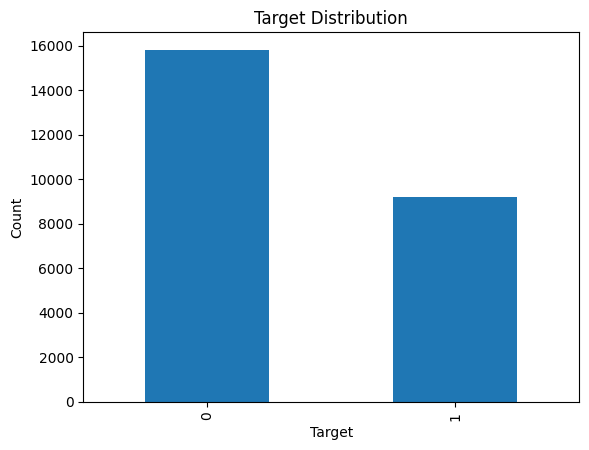

In [14]:
# ============================================================
# CELL 14 - PLOT TARGET DISTRIBUTION
# ============================================================

ax = df["target"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Target Distribution")
ax.set_xlabel("Target")
ax.set_ylabel("Count")
plt.show()


In [15]:
# ============================================================
# CELL 15 - IDENTIFY FEATURE GROUPS
# ============================================================

target_col = "target"

categorical_cols = [
    "region",
    "education_level",
    "occupation",
    "channel",
    "device_type",
    "membership_tier",
    "product_category"
]

numerical_cols = [
    "age",
    "years_experience",
    "monthly_sessions",
    "avg_basket_value",
    "days_since_last_activity",
    "credit_utilization",
    "income_estimate"
]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['region', 'education_level', 'occupation', 'channel', 'device_type', 'membership_tier', 'product_category']
Numerical columns: ['age', 'years_experience', 'monthly_sessions', 'avg_basket_value', 'days_since_last_activity', 'credit_utilization', 'income_estimate']


In [16]:
# ============================================================
# CELL 16 - DESCRIPTIVE STATISTICS FOR NUMERICAL FEATURES
# ============================================================

df[numerical_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,25000.0,38.219560,10.647932,18.000000,31.000000,38.000000,45.000000,75.000000
years_experience,25000.0,9.202153,5.671927,0.000000,4.959526,9.057554,13.096560,38.959657
monthly_sessions,25000.0,18.067264,7.825979,1.000000,12.660726,18.072925,23.396889,50.716909
avg_basket_value,25000.0,220.785423,93.631372,10.000000,156.884826,220.702856,283.812442,607.174946
days_since_last_activity,25000.0,25.076940,25.041773,0.002192,7.256385,17.279080,34.486706,180.000000
credit_utilization,25000.0,0.417648,0.187160,0.001224,0.273926,0.407943,0.552559,0.976049
income_estimate,25000.0,62131.134260,21744.066363,12000.000000,47294.335424,62004.440615,76885.798966,149622.476065


In [17]:
# ============================================================
# CELL 17 - DESCRIPTIVE STATISTICS FOR CATEGORICAL FEATURES
# ============================================================

for col in categorical_cols:
    print("\n" + "=" * 60)
    print("Column:", col)
    print(df[col].value_counts().head(10))



Column: region
region
Coastal    4969
North      4532
West       4317
South      4019
East       3633
Central    3530
Name: count, dtype: int64

Column: education_level
education_level
Bachelors     7564
HighSchool    6974
Masters       5012
Diploma       3938
PhD           1512
Name: count, dtype: int64

Column: occupation
occupation
HR             2338
Finance        2334
Legal          2310
Support        2302
Retail         2284
Operations     2267
Healthcare     2265
Engineering    2260
Marketing      2237
Sales          2233
Name: count, dtype: int64

Column: channel
channel
Web        10325
Mobile      9717
Partner     2562
Branch      2396
Name: count, dtype: int64

Column: device_type
device_type
Mobile     13676
Desktop     8804
Tablet      2520
Name: count, dtype: int64

Column: membership_tier
membership_tier
Bronze      11500
Silver       7059
Gold         4488
Platinum     1953
Name: count, dtype: int64

Column: product_category
product_category
B    3686
G    3639
E    

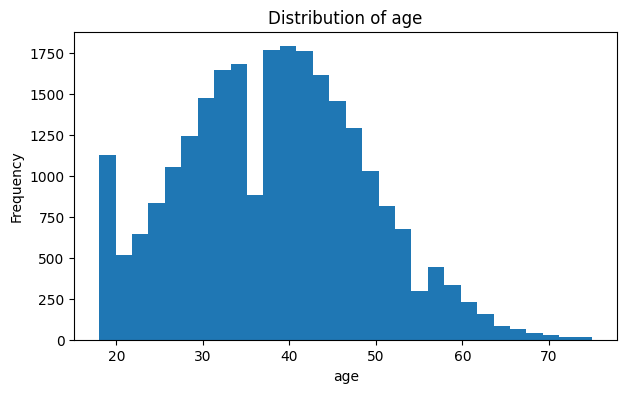

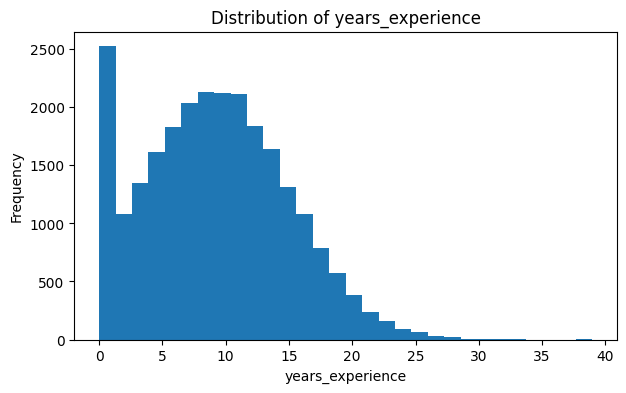

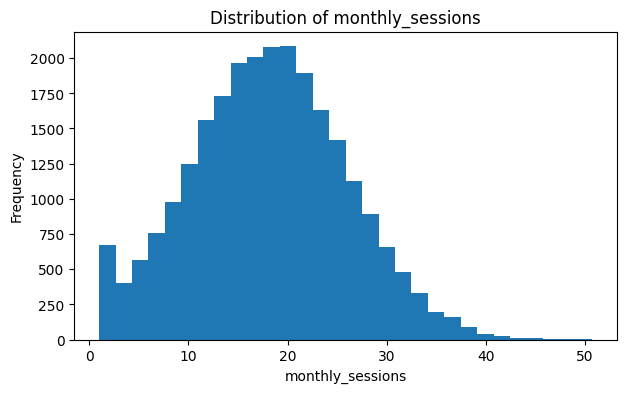

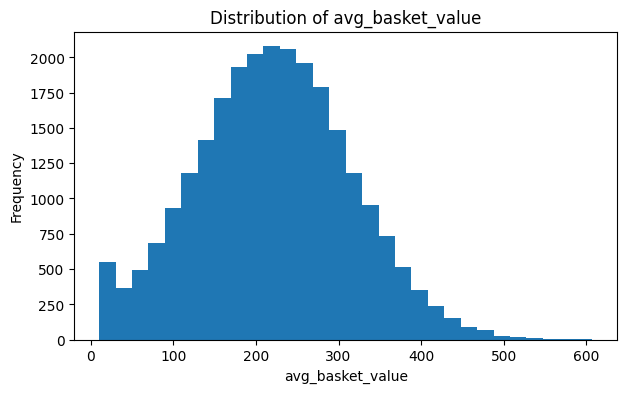

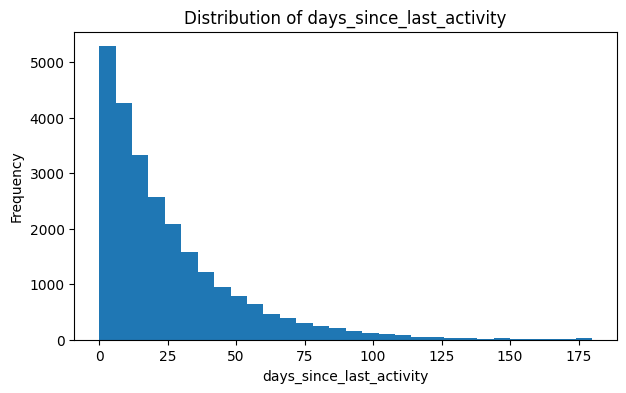

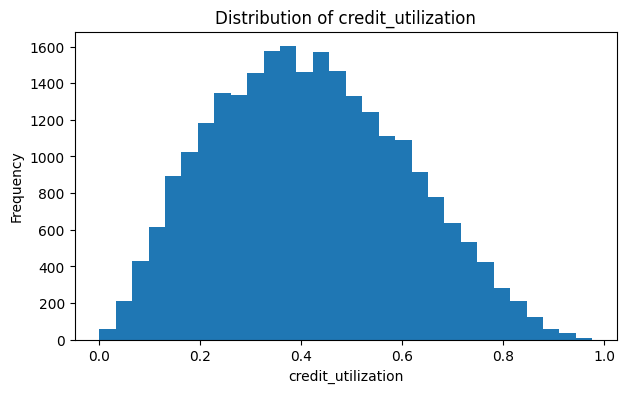

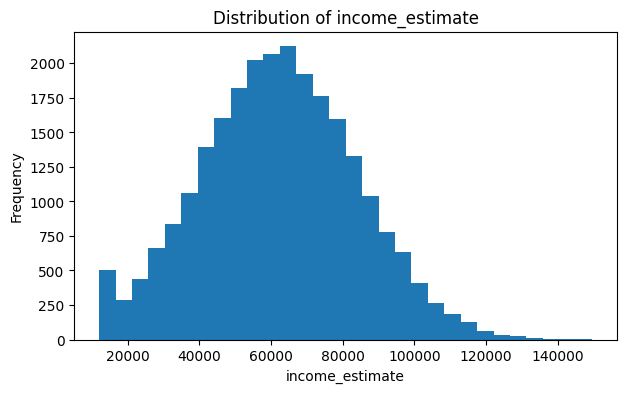

In [18]:
# ============================================================
# CELL 18 - NUMERICAL HISTOGRAMS
# ============================================================

for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [19]:
# ============================================================
# CELL 19 - TARGET RATE BY CATEGORICAL FEATURE
# ============================================================

for col in categorical_cols:
    summary = df.groupby(col)["target"].mean().sort_values(ascending=False)
    print("\n" + "=" * 70)
    print(f"Target rate by {col}")
    display((summary * 100).round(2).to_frame("target_rate_percent"))



Target rate by region


,target_rate_percent
region,
Coastal,40.31
West,37.53
North,37.27
Central,35.52
East,34.43
South,33.99



Target rate by education_level


,target_rate_percent
education_level,
PhD,46.23
Masters,43.46
Bachelors,39.01
Diploma,32.99
HighSchool,29.48



Target rate by occupation


...

,target_rate_percent
device_type,
Mobile,37.32
Desktop,36.09
Tablet,35.79



Target rate by membership_tier


,target_rate_percent
membership_tier,
Platinum,49.92
Gold,43.52
Silver,37.23
Bronze,31.54



Target rate by product_category


,target_rate_percent
product_category,
D,37.61
A,37.13
G,37.02
F,36.89
C,36.62
E,36.18
B,35.73


In [20]:
# ============================================================
# CELL 20 - CORRELATION MATRIX FOR NUMERICAL FEATURES
# ============================================================

corr_df = df[numerical_cols + [target_col]].corr(numeric_only=True)
corr_df


,age,years_experience,monthly_sessions,avg_basket_value,days_since_last_activity,credit_utilization,income_estimate,target
age,1.000000,0.002062,-0.009442,0.005747,0.003085,-0.005472,-0.008760,0.048477
years_experience,0.002062,1.000000,0.008412,-0.004154,0.004213,-0.000218,-0.001782,0.121772
monthly_sessions,-0.009442,0.008412,1.000000,-0.009745,0.002703,-0.001359,-0.019122,0.109446
avg_basket_value,0.005747,-0.004154,-0.009745,1.000000,-0.005268,0.000081,0.007994,0.169487
days_since_last_activity,0.003085,0.004213,0.002703,-0.005268,1.000000,0.005303,-0.001463,-0.168896
credit_utilization,-0.005472,-0.000218,-0.001359,0.000081,0.005303,1.000000,-0.005184,-0.062960
income_estimate,-0.008760,-0.001782,-0.019122,0.007994,-0.001463,-0.005184,1.000000,0.155603
target,0.048477,0.121772,0.109446,0.169487,-0.168896,-0.062960,0.155603,1.000000


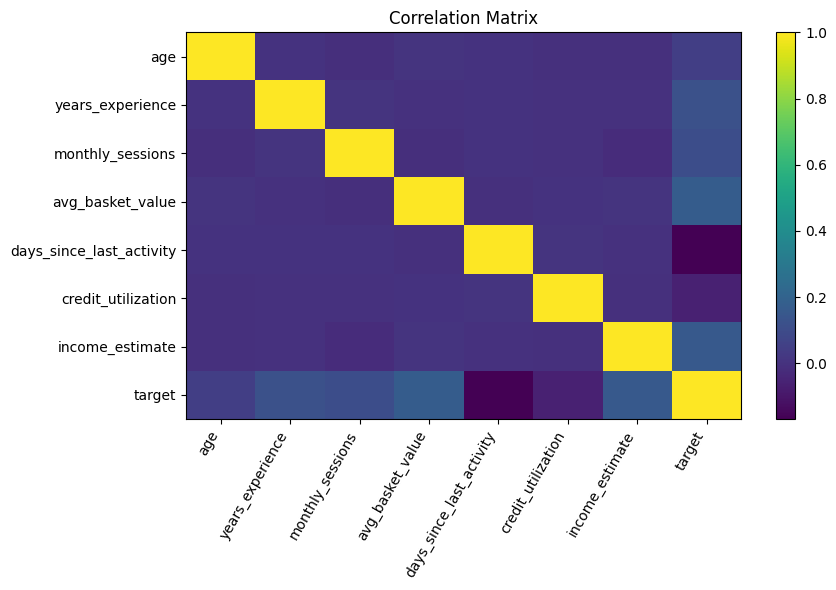

In [21]:
# ============================================================
# CELL 21 - PLOT CORRELATION MATRIX
# ============================================================

plt.figure(figsize=(9, 6))
plt.imshow(corr_df, aspect="auto")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=60, ha="right")
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title("Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


## Data Preprocessing Plan

We will prepare the data as follows:

### Numerical features
- median imputation
- standard scaling

### Categorical features
- label encoding for embedding inputs
- unknown category handling
- vocabulary-size tracking for each feature

### Target
- binary classification label


In [22]:
# ============================================================
# CELL 22 - TRAIN / VALID / TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df[target_col]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df[target_col]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (16000, 15)
Val shape: (4000, 15)
Test shape: (5000, 15)


In [23]:
# ============================================================
# CELL 23 - SPLIT FEATURES AND TARGET
# ============================================================

X_train = train_df[categorical_cols + numerical_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[categorical_cols + numerical_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[categorical_cols + numerical_cols].copy()
y_test = test_df[target_col].copy()

print(X_train.shape, X_val.shape, X_test.shape)


(16000, 14) (4000, 14) (5000, 14)


In [24]:
# ============================================================
# CELL 24 - FIT NUMERICAL PREPROCESSOR
# ============================================================

numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()

X_train_num = numeric_imputer.fit_transform(X_train[numerical_cols])
X_val_num = numeric_imputer.transform(X_val[numerical_cols])
X_test_num = numeric_imputer.transform(X_test[numerical_cols])

X_train_num = numeric_scaler.fit_transform(X_train_num)
X_val_num = numeric_scaler.transform(X_val_num)
X_test_num = numeric_scaler.transform(X_test_num)

print("Numerical arrays prepared.")


Numerical arrays prepared.


In [25]:
# ============================================================
# CELL 25 - ENCODE CATEGORICAL FEATURES FOR EMBEDDINGS
# ============================================================

label_encoders = {}
cat_vocab_sizes = {}
cat_embedding_dims = {}

X_train_cat = {}
X_val_cat = {}
X_test_cat = {}

for col in categorical_cols:
    le = LabelEncoder()
    combined_values = pd.concat([X_train[col], X_val[col], X_test[col]], axis=0).astype(str)
    le.fit(combined_values)

    X_train_cat[col] = le.transform(X_train[col].astype(str))
    X_val_cat[col] = le.transform(X_val[col].astype(str))
    X_test_cat[col] = le.transform(X_test[col].astype(str))

    vocab_size = len(le.classes_)
    embedding_dim = min(50, math.ceil(vocab_size ** 0.5) + 1)

    label_encoders[col] = le
    cat_vocab_sizes[col] = vocab_size
    cat_embedding_dims[col] = embedding_dim

display(pd.DataFrame({
    "vocab_size": cat_vocab_sizes,
    "embedding_dim": cat_embedding_dims
}).sort_index())


,vocab_size,embedding_dim
channel,4,3
device_type,3,3
education_level,5,4
membership_tier,4,3
occupation,11,5
product_category,7,4
region,6,4


In [26]:
# ============================================================
# CELL 26 - CONVERT CATEGORICAL ARRAYS TO NUMPY
# ============================================================

for col in categorical_cols:
    X_train_cat[col] = np.asarray(X_train_cat[col], dtype="int32")
    X_val_cat[col] = np.asarray(X_val_cat[col], dtype="int32")
    X_test_cat[col] = np.asarray(X_test_cat[col], dtype="int32")

X_train_num = np.asarray(X_train_num, dtype="float32")
X_val_num = np.asarray(X_val_num, dtype="float32")
X_test_num = np.asarray(X_test_num, dtype="float32")

y_train_array = np.asarray(y_train, dtype="float32")
y_val_array = np.asarray(y_val, dtype="float32")
y_test_array = np.asarray(y_test, dtype="float32")

print("All arrays converted to model-ready format.")


All arrays converted to model-ready format.


In [27]:
# ============================================================
# CELL 27 - BUILD MODEL INPUT DICTIONARIES
# ============================================================

train_inputs = {f"{col}_input": X_train_cat[col] for col in categorical_cols}
val_inputs = {f"{col}_input": X_val_cat[col] for col in categorical_cols}
test_inputs = {f"{col}_input": X_test_cat[col] for col in categorical_cols}

train_inputs["numerical_input"] = X_train_num
val_inputs["numerical_input"] = X_val_num
test_inputs["numerical_input"] = X_test_num

print("Input dictionary keys:", list(train_inputs.keys()))


Input dictionary keys: ['region_input', 'education_level_input', 'occupation_input', 'channel_input', 'device_type_input', 'membership_tier_input', 'product_category_input', 'numerical_input']


## Embedding-Based ANN Architecture

The network uses:
- one embedding branch per categorical feature
- one numerical dense input branch
- concatenation of all representations
- shared dense layers
- binary prediction head

This allows the model to learn latent representations for each category, instead of relying only on sparse one-hot encodings.


In [28]:
# ============================================================
# CELL 28 - BUILD EMBEDDING MODEL
# ============================================================

def build_tabular_embedding_model(cat_vocab_sizes, cat_embedding_dims, num_numeric_features):
    input_layers = []
    embedding_outputs = []

    for col in categorical_cols:
        inp = Input(shape=(1,), name=f"{col}_input")
        emb = Embedding(
            input_dim=cat_vocab_sizes[col],
            output_dim=cat_embedding_dims[col],
            name=f"{col}_embedding"
        )(inp)
        emb = Flatten(name=f"{col}_flatten")(emb)

        input_layers.append(inp)
        embedding_outputs.append(emb)

    numerical_input = Input(shape=(num_numeric_features,), name="numerical_input")
    input_layers.append(numerical_input)

    x = Concatenate(name="feature_concat")(embedding_outputs + [numerical_input])

    x = Dense(128, activation="relu", name="dense_128")(x)
    x = BatchNormalization(name="bn_128")(x)
    x = Dropout(0.30, name="dropout_128")(x)

    x = Dense(64, activation="relu", name="dense_64")(x)
    x = BatchNormalization(name="bn_64")(x)
    x = Dropout(0.25, name="dropout_64")(x)

    x = Dense(32, activation="relu", name="dense_32")(x)
    x = Dropout(0.20, name="dropout_32")(x)

    output = Dense(1, activation="sigmoid", name="target_probability")(x)

    model = Model(inputs=input_layers, outputs=output, name="Tabular_Embedding_ANN")
    return model


In [29]:
# ============================================================
# CELL 29 - INITIALIZE MODEL
# ============================================================

model = build_tabular_embedding_model(
    cat_vocab_sizes=cat_vocab_sizes,
    cat_embedding_dims=cat_embedding_dims,
    num_numeric_features=len(numerical_cols)
)

model.summary()


Model: "Tabular_Embedding_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ region_input (InputLayer)     │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ education_level_input         │ (None, 1)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ occupation_input (InputLayer) │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ channel_input (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ device_type_input             │ (None, 1)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ membership_tier_input         │ (None, 1)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ product_category_input        │ (None, 1)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ region_embedding (Embedding)  │ (None, 1, 4)              │              24 │ region_input[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ education_level_embedding     │ (None, 1, 4)              │              20 │ education_level_input[0][… │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ occupation_embedding          │ (None, 1, 5)              │              55 │ occupation_input[0][0]     │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ channel_embedding (Embedding) │ (None, 1, 3)              │              12 │ channel_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ device_type_embedding         │ (None, 1, 3)              │               9 │ device_type_input[0][0]    │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ membership_tier_embedding     │ (None, 1, 3)              │              12 │ membership_tier_input[0][… │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 15,649 (61.13 KB)

 Trainable params: 15,265 (59.63 KB)

 Non-trainable params: 384 (1.50 KB)

In [30]:
# ============================================================
# CELL 30 - COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model compiled successfully.")


Model compiled successfully.


In [31]:
# ============================================================
# CELL 31 - DEFINE CALLBACKS
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]


In [32]:
# ============================================================
# CELL 32 - COMPUTE CLASS WEIGHTS
# ============================================================

class_counts = y_train.value_counts().sort_index()
total_count = class_counts.sum()

class_weight = {
    0: total_count / (2 * class_counts.loc[0]),
    1: total_count / (2 * class_counts.loc[1])
}

print("Class distribution in train:")
print(class_counts)
print("\nClass weights:", class_weight)


Class distribution in train:
target
0    10123
1     5877
Name: count, dtype: int64

Class weights: {0: 0.7902795613948435, 1: 1.36123872724179}


In [33]:
# ============================================================
# CELL 33 - TRAIN MODEL
# ============================================================

history = model.fit(
    train_inputs,
    y_train_array,
    validation_data=(val_inputs, y_val_array),
    epochs=25,
    batch_size=256,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)


Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5748 - auc: 0.6246 - loss: 0.7058 - val_accuracy: 0.6607 - val_auc: 0.6719 - val_loss: 0.6428 - learning_rate: 0.0010
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6169 - auc: 0.6668 - loss: 0.6598 - val_accuracy: 0.6603 - val_auc: 0.6793 - val_loss: 0.6349 - learning_rate: 0.0010
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6351 - auc: 0.6844 - loss: 0.6427 - val_accuracy: 0.6687 - val_auc: 0.6879 - val_loss: 0.6217 - learning_rate: 0.0010
Epoch 4/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6424 - auc: 0.6982 - loss: 0.6328 - val_accuracy: 0.6655 - val_auc: 0.6964 - val_loss: 0.6135 - learning_rate: 0.0010
Epoch 5/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6466 - auc: 0.7051 - loss: 0.6272 - val_accuracy: 0.6683 - val_auc: 0.7012 - val_loss: 0.6068 - learning_rate: 0.0010
Epoch 6/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6586 - auc: 0.7150 - loss:

In [34]:
# ============================================================
# CELL 34 - SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

history_df.head()


,accuracy,auc,loss,val_accuracy,val_auc,val_loss,learning_rate
0,0.574812,0.624557,0.705822,0.66075,0.671934,0.642836,0.001
1,0.616938,0.666773,0.659785,0.66025,0.679287,0.634917,0.001
2,0.635125,0.684391,0.642670,0.66875,0.687927,0.621707,0.001
3,0.642375,0.698170,0.632795,0.66550,0.696390,0.613485,0.001
4,0.646625,0.705057,0.627211,0.66825,0.701209,0.606840,0.001


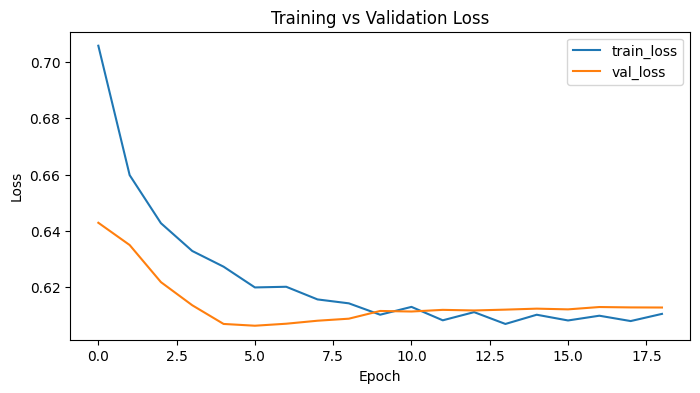

In [35]:
# ============================================================
# CELL 35 - PLOT LOSS CURVES
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


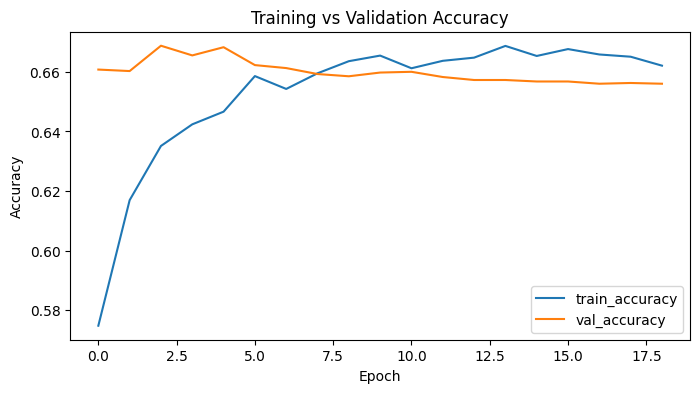

In [36]:
# ============================================================
# CELL 36 - PLOT ACCURACY CURVES
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


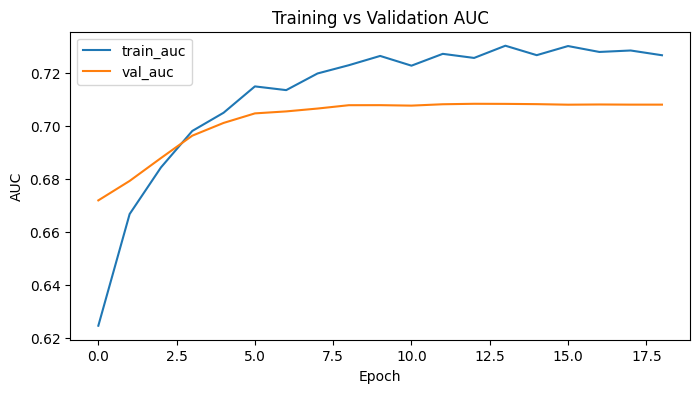

In [37]:
# ============================================================
# CELL 37 - PLOT AUC CURVES
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(history_df["auc"], label="train_auc")
plt.plot(history_df["val_auc"], label="val_auc")
plt.title("Training vs Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()


In [38]:
# ============================================================
# CELL 38 - SAVE MODEL
# ============================================================

model_path = OUTPUT_DIR / "tabular_embedding_ann.keras"
model.save(model_path)

print("Model saved to:", model_path.resolve())


Model saved to: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Tabular Deep Learning with Embeddings\tabular_embeddings_outputs\tabular_embedding_ann.keras


In [39]:
# ============================================================
# CELL 39 - GENERATE MODEL DIAGRAM
# ============================================================

diagram_path = OUTPUT_DIR / "tabular_embedding_model_architecture.png"

try:
    plot_model(
        model,
        to_file=str(diagram_path),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=False,
        dpi=120
    )
    print("Model diagram saved:", diagram_path.resolve())
except Exception as e:
    print("Could not generate model diagram automatically.")
    print("Reason:", str(e))


You must install pydot (`pip install pydot`) for `plot_model` to work.
Model diagram saved: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Tabular Deep Learning with Embeddings\tabular_embeddings_outputs\tabular_embedding_model_architecture.png


## Model Architecture Summary

The model architecture diagram is generated in the output folder when Graphviz / pydot is available.  
If the image is not generated in your environment, the model summary still documents the architecture clearly.


In [40]:
# ============================================================
# CELL 40 - RELOAD MODEL
# ============================================================

reloaded_model = tf.keras.models.load_model(model_path)
print("Reloaded model successfully.")


Reloaded model successfully.


In [41]:
# ============================================================
# CELL 41 - PREDICT ON VALIDATION SET
# ============================================================

val_pred_prob = reloaded_model.predict(val_inputs, batch_size=512).ravel()
val_pred_label = (val_pred_prob >= 0.50).astype(int)

print("Validation predictions generated.")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Validation predictions generated.


In [42]:
# ============================================================
# CELL 42 - PREDICT ON TEST SET
# ============================================================

test_pred_prob = reloaded_model.predict(test_inputs, batch_size=512).ravel()
test_pred_label = (test_pred_prob >= 0.50).astype(int)

print("Test predictions generated.")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Test predictions generated.


In [43]:
# ============================================================
# CELL 43 - CREATE EVALUATION FUNCTION
# ============================================================

def evaluate_binary_model(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob)
    }
    return metrics


In [44]:
# ============================================================
# CELL 44 - VALIDATION METRICS
# ============================================================

val_metrics = evaluate_binary_model(y_val_array, val_pred_prob, threshold=0.50)
pd.DataFrame([val_metrics]).round(4)


,accuracy,precision,recall,f1,roc_auc,log_loss
0,0.6572,0.5295,0.599,0.5621,0.7085,0.6116


In [45]:
# ============================================================
# CELL 45 - TEST METRICS
# ============================================================

test_metrics = evaluate_binary_model(y_test_array, test_pred_prob, threshold=0.50)
pd.DataFrame([test_metrics]).round(4)


,accuracy,precision,recall,f1,roc_auc,log_loss
0,0.6706,0.5436,0.6445,0.5898,0.7294,0.5994


## Evaluation Metrics

For this project, the correct metrics are classification metrics such as:
- accuracy
- precision
- recall
- F1-score
- ROC-AUC
- log loss

### Important note
For a tabular binary classification project like this, **BLEU is not applicable**.  
BLEU is used for language generation tasks, not tabular classification.


In [46]:
# ============================================================
# CELL 46 - CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_test_array.astype(int),
    test_pred_label.astype(int),
    target_names=["Class_0", "Class_1"],
    digits=4
)

print(report)


              precision    recall  f1-score   support

     Class_0     0.7686    0.6857    0.7248      3163
     Class_1     0.5436    0.6445    0.5898      1837

    accuracy                         0.6706      5000
   macro avg     0.6561    0.6651    0.6573      5000
weighted avg     0.6859    0.6706    0.6752      5000



In [47]:
# ============================================================
# CELL 47 - CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test_array.astype(int), test_pred_label.astype(int))
cm_df = pd.DataFrame(cm, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"])
cm_df


,Pred_0,Pred_1
Actual_0,2169,994
Actual_1,653,1184


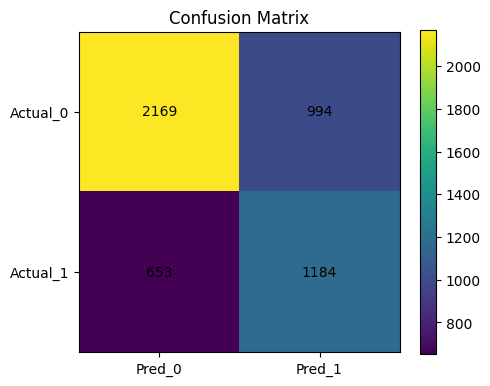

In [48]:
# ============================================================
# CELL 48 - PLOT CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["Pred_0", "Pred_1"])
plt.yticks([0, 1], ["Actual_0", "Actual_1"])
plt.title("Confusion Matrix")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()


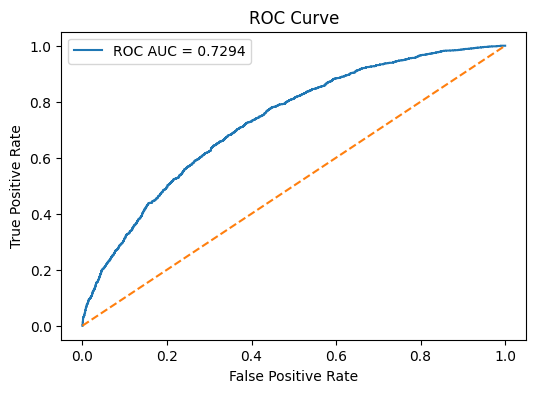

In [49]:
# ============================================================
# CELL 49 - ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(y_test_array, test_pred_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_val:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


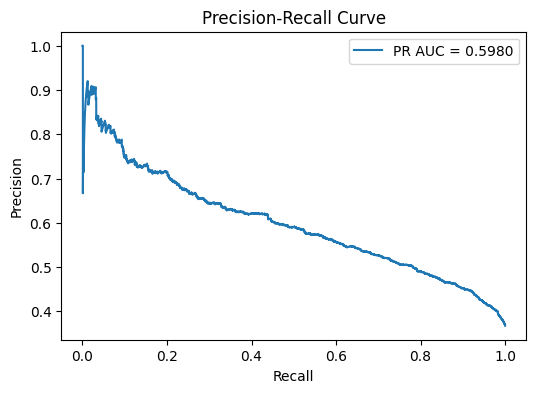

In [50]:
# ============================================================
# CELL 50 - PRECISION RECALL CURVE
# ============================================================

precision_vals, recall_vals, _ = precision_recall_curve(y_test_array, test_pred_prob)
pr_auc_val = auc(recall_vals, precision_vals)

plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc_val:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [51]:
# ============================================================
# CELL 51 - THRESHOLD ANALYSIS
# ============================================================

thresholds = np.arange(0.10, 0.91, 0.05)

rows = []
for thr in thresholds:
    preds = (test_pred_prob >= thr).astype(int)
    rows.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_test_array, preds),
        "precision": precision_score(y_test_array, preds, zero_division=0),
        "recall": recall_score(y_test_array, preds, zero_division=0),
        "f1": f1_score(y_test_array, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)
threshold_df.round(4)


,threshold,accuracy,precision,recall,f1
0,0.10,0.3886,0.3751,0.9973,0.5452
1,0.15,0.4174,0.3858,0.9891,0.5551
2,0.20,0.4548,0.4010,0.9804,0.5692
3,0.25,0.4928,0.4170,0.9554,0.5805
4,0.30,0.5366,0.4382,0.9271,0.5951
5,0.35,0.5738,0.4585,0.8846,0.6040
6,0.40,0.6084,0.4808,0.8225,0.6068
7,0.45,0.6424,0.5091,0.7458,0.6051
8,0.50,0.6706,0.5436,0.6445,0.5898
9,0.55,0.6852,0.5788,0.5259,0.5511


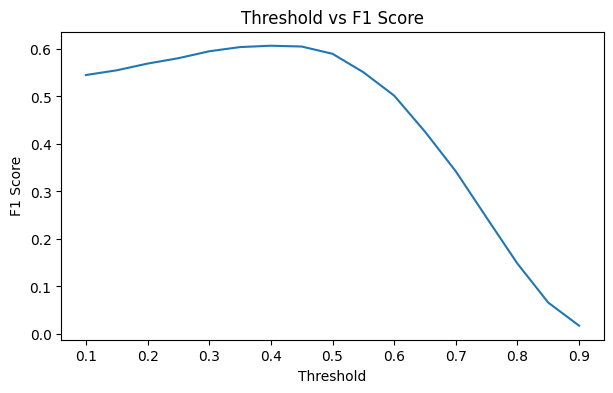

In [52]:
# ============================================================
# CELL 52 - PLOT THRESHOLD VS F1
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["f1"])
plt.title("Threshold vs F1 Score")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()


## Baseline Comparison

A strong portfolio project should not stop at one model.  
We compare the embedding-based ANN against a traditional machine learning baseline.

### Baseline used
- Random Forest with one-hot encoding
- Optional XGBoost if available


In [53]:
# ============================================================
# CELL 53 - PREPARE ONE-HOT DATA FOR BASELINE
# ============================================================

X_train_baseline = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
X_val_baseline = pd.get_dummies(X_val, columns=categorical_cols, drop_first=False)
X_test_baseline = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False)

X_val_baseline = X_val_baseline.reindex(columns=X_train_baseline.columns, fill_value=0)
X_test_baseline = X_test_baseline.reindex(columns=X_train_baseline.columns, fill_value=0)

print("Baseline train shape:", X_train_baseline.shape)


Baseline train shape: (16000, 47)


In [54]:
# ============================================================
# CELL 54 - TRAIN RANDOM FOREST BASELINE
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train_baseline, y_train)
print("Random Forest baseline trained.")


Random Forest baseline trained.


In [55]:
# ============================================================
# CELL 55 - RANDOM FOREST EVALUATION
# ============================================================

rf_pred_prob = rf_model.predict_proba(X_test_baseline)[:, 1]
rf_pred_label = (rf_pred_prob >= 0.50).astype(int)

rf_metrics = evaluate_binary_model(y_test_array, rf_pred_prob, threshold=0.50)
pd.DataFrame([rf_metrics]).round(4)


,accuracy,precision,recall,f1,roc_auc,log_loss
0,0.6772,0.6756,0.2335,0.3471,0.7225,0.5961


In [56]:
# ============================================================
# CELL 56 - OPTIONAL XGBOOST BASELINE
# ============================================================

if XGBOOST_AVAILABLE:
    xgb_model = XGBClassifier(
        n_estimators=250,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.90,
        colsample_bytree=0.90,
        eval_metric="logloss",
        random_state=SEED
    )
    xgb_model.fit(X_train_baseline, y_train)
    xgb_pred_prob = xgb_model.predict_proba(X_test_baseline)[:, 1]
    xgb_metrics = evaluate_binary_model(y_test_array, xgb_pred_prob, threshold=0.50)
    display(pd.DataFrame([xgb_metrics]).round(4))
else:
    print("XGBoost not available in this environment.")


XGBoost not available in this environment.


In [57]:
# ============================================================
# CELL 57 - MODEL COMPARISON TABLE
# ============================================================

comparison_rows = [
    {"model": "Embedding_ANN", **test_metrics},
    {"model": "RandomForest", **rf_metrics}
]

if XGBOOST_AVAILABLE:
    comparison_rows.append({"model": "XGBoost", **xgb_metrics})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.round(4)


,model,accuracy,precision,recall,f1,roc_auc,log_loss
0,Embedding_ANN,0.6706,0.5436,0.6445,0.5898,0.7294,0.5994
1,RandomForest,0.6772,0.6756,0.2335,0.3471,0.7225,0.5961


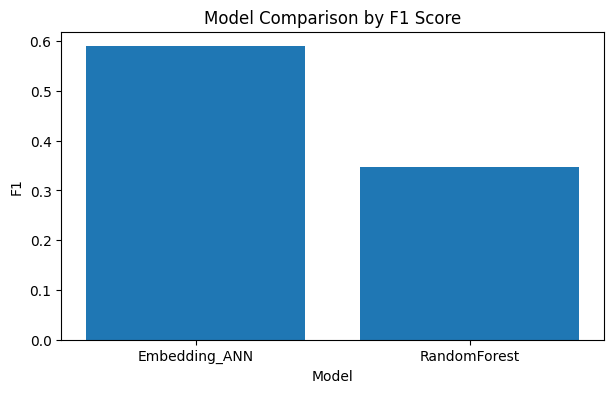

In [58]:
# ============================================================
# CELL 58 - PLOT MODEL COMPARISON (F1)
# ============================================================

plt.figure(figsize=(7, 4))
plt.bar(comparison_df["model"], comparison_df["f1"])
plt.title("Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1")
plt.show()


## Feature Importance / Explainability

Neural networks with embeddings are powerful, but it is still useful to provide explainability.

In this notebook we include:
- permutation importance on the baseline model
- embedding inspection
- probability bucket analysis
- error slicing


In [59]:
# ============================================================
# CELL 59 - PERMUTATION IMPORTANCE ON RANDOM FOREST
# ============================================================

perm_result = permutation_importance(
    rf_model,
    X_test_baseline,
    y_test,
    n_repeats=5,
    random_state=SEED,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test_baseline.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.head(20)


,feature,importance_mean,importance_std
3,avg_basket_value,0.01648,0.001982
4,days_since_last_activity,0.01368,0.002002
6,income_estimate,0.01280,0.002356
1,years_experience,0.00936,0.003574
2,monthly_sessions,0.00880,0.002387
36,membership_tier_Bronze,0.00516,0.002354
38,membership_tier_Platinum,0.00396,0.000686
37,membership_tier_Gold,0.00248,0.001342
0,age,0.00224,0.000843
5,credit_utilization,0.00224,0.001054


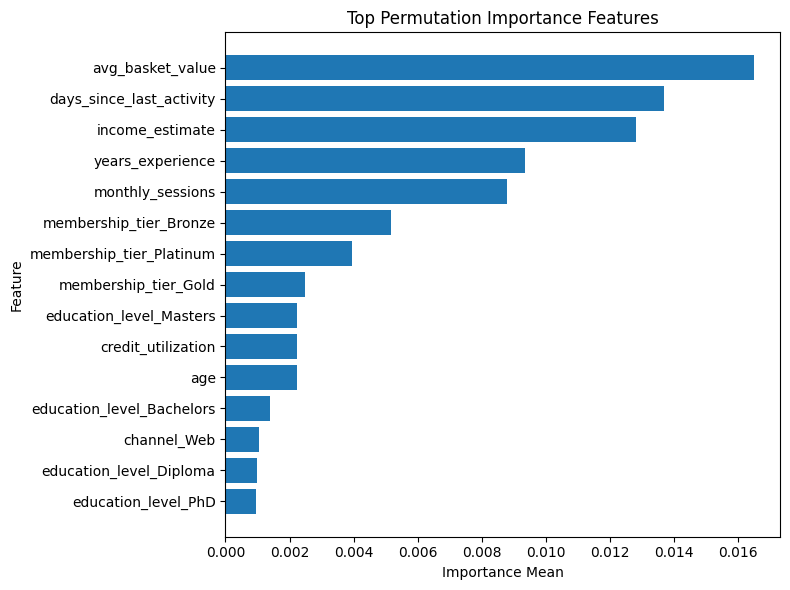

In [60]:
# ============================================================
# CELL 60 - PLOT TOP PERMUTATION IMPORTANCE FEATURES
# ============================================================

top_perm = perm_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title("Top Permutation Importance Features")
plt.xlabel("Importance Mean")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [61]:
# ============================================================
# CELL 61 - EXTRACT EMBEDDING MATRICES
# ============================================================

embedding_weights = {}

for col in categorical_cols:
    layer = reloaded_model.get_layer(f"{col}_embedding")
    weights = layer.get_weights()[0]
    embedding_weights[col] = weights
    print(f"{col}: shape = {weights.shape}")


region: shape = (6, 4)
education_level: shape = (5, 4)
occupation: shape = (11, 5)
channel: shape = (4, 3)
device_type: shape = (3, 3)
membership_tier: shape = (4, 3)
product_category: shape = (7, 4)


In [62]:
# ============================================================
# CELL 62 - INSPECT ONE EMBEDDING TABLE
# ============================================================

selected_col = "membership_tier"
selected_weights = embedding_weights[selected_col]

embedding_df = pd.DataFrame(selected_weights)
embedding_df.index = label_encoders[selected_col].classes_
embedding_df.head()


,0,1,2
Bronze,0.191342,-0.174675,0.021527
Gold,-0.062463,0.172655,-0.008917
Platinum,-0.191579,0.287475,0.019273
Silver,0.029970,-0.057090,0.016751


In [63]:
# ============================================================
# CELL 63 - SAMPLE PREDICTIONS TABLE
# ============================================================

sample_results = test_df.copy()
sample_results["pred_probability"] = test_pred_prob
sample_results["pred_label"] = test_pred_label
sample_results["error_flag"] = (sample_results["target"] != sample_results["pred_label"]).astype(int)

sample_results[[
    "region", "education_level", "occupation", "membership_tier",
    "income_estimate", "avg_basket_value", "monthly_sessions",
    "target", "pred_probability", "pred_label", "error_flag"
]].head(20)


,region,education_level,occupation,membership_tier,income_estimate,avg_basket_value,monthly_sessions,target,pred_probability,pred_label,error_flag
0,North,Diploma,Retail,Silver,86688.487458,242.421783,17.369753,1,0.574085,1,0
1,South,HighSchool,Healthcare,Bronze,35832.395176,142.092195,1.000000,0,0.056012,0,0
2,Coastal,Diploma,Healthcare,Bronze,94821.638539,104.723651,15.539262,0,0.103393,0,0
3,West,Masters,Finance,Silver,49587.772572,152.752279,15.050143,1,0.604235,1,0
4,West,Diploma,Legal,Silver,55108.087133,224.169476,26.606479,1,0.567380,1,0
5,West,HighSchool,Sales,Bronze,69777.379615,394.605379,17.806601,1,0.619406,1,0
6,North,Bachelors,Support,Gold,77540.862180,247.489675,13.439021,0,0.329045,0,0
7,Central,HighSchool,Support,Silver,89459.551651,310.413826,13.919538,1,0.613217,1,0
8,Central,Diploma,Marketing,Gold,20478.117148,290.010418,18.357501,0,0.390865,0,0
9,East,Masters,Support,Bronze,48288.077966,300.014854,2.875790,0,0.385699,0,0


In [64]:
# ============================================================
# CELL 64 - TOP HIGH-CONFIDENCE POSITIVE PREDICTIONS
# ============================================================

sample_results.sort_values("pred_probability", ascending=False).head(15)[[
    "region",
    "education_level",
    "occupation",
    "membership_tier",
    "income_estimate",
    "avg_basket_value",
    "monthly_sessions",
    "target",
    "pred_probability"
]]


,region,education_level,occupation,membership_tier,income_estimate,avg_basket_value,monthly_sessions,target,pred_probability
2522,Coastal,Bachelors,Finance,Silver,101180.975820,541.561109,27.633285,1,0.968311
1860,North,PhD,Marketing,Bronze,57692.834389,545.700937,24.576970,1,0.963200
2281,Coastal,Masters,HR,Gold,102233.072241,318.538386,18.490699,0,0.930778
1573,West,HighSchool,Support,Gold,103082.109264,431.376144,23.653124,1,0.929384
288,South,PhD,Legal,Gold,114453.879903,314.010114,19.350460,1,0.921973
4212,Coastal,Bachelors,Education,Gold,86454.259430,397.163783,16.359697,1,0.921310
911,North,Bachelors,Legal,Silver,81847.129060,399.448310,31.350622,0,0.921304
1000,Coastal,Masters,Healthcare,Platinum,61539.553679,368.467122,25.251129,1,0.921121
613,West,Masters,Education,Platinum,87982.784883,285.753984,23.480575,1,0.912465
24,North,Bachelors,Sales,Platinum,72786.557253,341.737028,29.161889,1,0.911770


In [65]:
# ============================================================
# CELL 65 - TOP HIGH-CONFIDENCE NEGATIVE PREDICTIONS
# ============================================================

sample_results.sort_values("pred_probability", ascending=True).head(15)[[
    "region",
    "education_level",
    "occupation",
    "membership_tier",
    "income_estimate",
    "avg_basket_value",
    "monthly_sessions",
    "target",
    "pred_probability"
]]


,region,education_level,occupation,membership_tier,income_estimate,avg_basket_value,monthly_sessions,target,pred_probability
3126,West,HighSchool,Support,Bronze,57656.834682,341.018021,1.000000,0,0.014609
2670,South,Masters,Finance,Bronze,19150.161191,167.611158,5.468085,0,0.015980
3806,West,HighSchool,Operations,Bronze,38244.437035,70.792045,6.524128,0,0.018867
2778,East,PhD,Sales,Bronze,38759.001183,208.138669,10.823990,0,0.020447
4126,South,HighSchool,Engineering,Bronze,38624.886224,145.421752,8.932969,0,0.020955
2805,Coastal,Bachelors,Healthcare,Bronze,36428.013259,194.360453,8.727322,0,0.022552
207,West,Bachelors,Operations,Bronze,63440.248137,130.901212,13.251582,0,0.023580
48,East,Diploma,Education,Bronze,23950.239811,179.691509,12.171032,0,0.024363
562,South,Diploma,Sales,Bronze,13072.931837,222.634746,20.491362,0,0.024696
1816,South,Diploma,Support,Bronze,53559.573009,252.869750,2.209778,0,0.029109


In [66]:
# ============================================================
# CELL 66 - FALSE POSITIVES
# ============================================================

false_positives = sample_results[(sample_results["target"] == 0) & (sample_results["pred_label"] == 1)]
false_positives.head(20)


,region,education_level,occupation,channel,device_type,membership_tier,product_category,age,years_experience,monthly_sessions,avg_basket_value,days_since_last_activity,credit_utilization,income_estimate,target,pred_probability,pred_label,error_flag
12,West,Bachelors,Sales,Mobile,Mobile,Gold,A,37,9.952771,23.991580,161.780973,8.914613,0.578362,60106.383848,0,0.633475,1,1
14,North,Bachelors,Retail,Mobile,Tablet,Gold,F,36,3.221889,37.319603,80.018783,14.304202,0.753105,74622.323832,0,0.560050,1,1
15,East,HighSchool,HR,Web,Desktop,Silver,G,38,7.823821,12.360266,337.847071,13.585271,0.789879,101785.088126,0,0.518787,1,1
16,West,Diploma,Sales,Web,Tablet,Bronze,G,34,5.848699,20.673673,315.729487,28.952689,0.226753,96933.285157,0,0.615136,1,1
17,Coastal,Bachelors,Legal,Web,Mobile,Bronze,C,30,12.523983,9.048279,185.743275,4.894549,0.404727,113287.955607,0,0.692245,1,1
19,West,Masters,HR,Mobile,Mobile,Silver,F,21,18.912369,20.382209,276.870859,18.997300,0.698729,99230.114838,0,0.793242,1,1
20,South,PhD,Support,Web,Tablet,Bronze,E,39,11.011902,12.338370,167.212186,7.183584,0.519738,90326.364386,0,0.610297,1,1
31,West,Diploma,Finance,Mobile,Mobile,Silver,C,47,16.695117,11.086076,162.426617,17.237038,0.612429,77703.679768,0,0.568634,1,1
37,North,Bachelors,Support,Mobile,Mobile,Gold,A,44,0.554969,8.253162,312.392679,5.424866,0.446385,80789.540831,0,0.700213,1,1
41,Coastal,Bachelors,HR,Web,Tablet,Gold,D,50,18.034679,30.979536,359.186383,26.974705,0.730010,80971.690136,0,0.862956,1,1


In [67]:
# ============================================================
# CELL 67 - FALSE NEGATIVES
# ============================================================

false_negatives = sample_results[(sample_results["target"] == 1) & (sample_results["pred_label"] == 0)]
false_negatives.head(20)


,region,education_level,occupation,channel,device_type,membership_tier,product_category,age,years_experience,monthly_sessions,avg_basket_value,days_since_last_activity,credit_utilization,income_estimate,target,pred_probability,pred_label,error_flag
25,Coastal,Bachelors,Operations,Web,Mobile,Silver,G,45,4.923247,26.344481,97.321989,12.674387,0.698897,65754.578989,1,0.458756,0,1
34,Coastal,Bachelors,HR,Web,Desktop,Bronze,G,46,7.297484,25.948715,107.000544,14.298109,0.686475,43584.195623,1,0.281743,0,1
36,Coastal,HighSchool,Operations,Web,Mobile,Silver,D,47,10.051277,30.078780,177.715827,3.747510,0.368503,28875.012109,1,0.392660,0,1
39,West,HighSchool,Marketing,Mobile,Mobile,Silver,C,59,8.476184,25.064783,300.718010,31.549332,0.603624,25526.130145,1,0.368030,0,1
46,East,Bachelors,Finance,Mobile,Desktop,Bronze,B,27,11.133677,19.015569,108.841534,11.505862,0.805578,63681.928761,1,0.305373,0,1
51,South,Diploma,Support,Web,Mobile,Bronze,B,54,7.682726,18.824090,171.399856,11.976998,0.362413,78062.609131,1,0.489429,0,1
64,Coastal,PhD,Healthcare,Mobile,Mobile,Silver,A,44,8.157099,16.795431,174.021026,67.644037,0.457346,68881.164634,1,0.343005,0,1
73,South,HighSchool,Finance,Web,Mobile,Bronze,A,39,0.000000,13.062519,174.754108,12.362606,0.410462,104154.056243,1,0.363826,0,1
77,Coastal,Masters,Healthcare,Mobile,Mobile,Bronze,F,44,1.565659,29.536275,200.555767,50.009405,0.285994,54098.000900,1,0.333466,0,1
79,Coastal,Bachelors,Retail,Mobile,Mobile,Bronze,C,39,2.045438,14.232199,140.326952,7.157024,0.173814,61925.328007,1,0.459619,0,1


In [68]:
# ============================================================
# CELL 68 - ERROR RATE BY MEMBERSHIP TIER
# ============================================================

error_by_tier = sample_results.groupby("membership_tier")["error_flag"].mean().sort_values(ascending=False)
(error_by_tier * 100).round(2).to_frame("error_rate_percent")


,error_rate_percent
membership_tier,
Gold,35.82
Silver,34.47
Platinum,33.10
Bronze,30.75


In [69]:
# ============================================================
# CELL 69 - ERROR RATE BY EDUCATION LEVEL
# ============================================================

error_by_education = sample_results.groupby("education_level")["error_flag"].mean().sort_values(ascending=False)
(error_by_education * 100).round(2).to_frame("error_rate_percent")


,error_rate_percent
education_level,
PhD,36.91
Bachelors,36.14
Masters,35.52
Diploma,32.45
HighSchool,27.36


In [70]:
# ============================================================
# CELL 70 - CALIBRATION-STYLE PROBABILITY BUCKETS
# ============================================================

sample_results["prob_bucket"] = pd.cut(
    sample_results["pred_probability"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

bucket_summary = sample_results.groupby("prob_bucket").agg(
    avg_pred_prob=("pred_probability", "mean"),
    actual_rate=("target", "mean"),
    count=("target", "size")
).reset_index()

bucket_summary


,prob_bucket,avg_pred_prob,actual_rate,count
0,"(-0.001, 0.1]",0.067595,0.043103,116
1,"(0.1, 0.2]",0.153971,0.078880,393
2,"(0.2, 0.3]",0.252757,0.161983,605
3,"(0.3, 0.4]",0.352061,0.258412,743
4,"(0.4, 0.5]",0.452306,0.338860,965
5,"(0.5, 0.6]",0.546791,0.440860,930
6,"(0.6, 0.7]",0.648054,0.557300,637
7,"(0.7, 0.8]",0.745578,0.640476,420
8,"(0.8, 0.9]",0.840062,0.774566,173
9,"(0.9, 1.0]",0.918856,0.888889,18


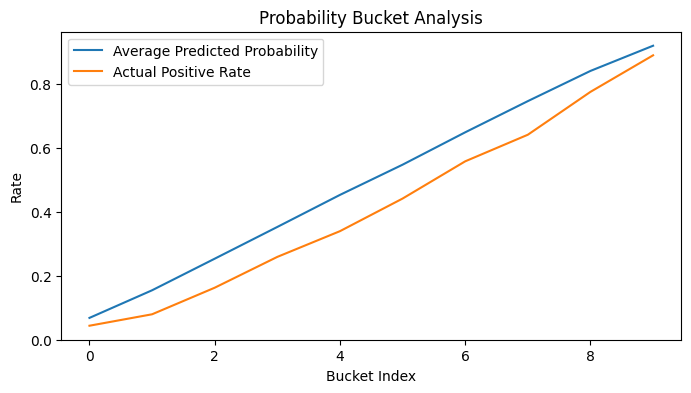

In [71]:
# ============================================================
# CELL 71 - PLOT PROBABILITY BUCKET ANALYSIS
# ============================================================

plot_df = bucket_summary.dropna().copy()

plt.figure(figsize=(8, 4))
plt.plot(plot_df["avg_pred_prob"], label="Average Predicted Probability")
plt.plot(plot_df["actual_rate"], label="Actual Positive Rate")
plt.title("Probability Bucket Analysis")
plt.xlabel("Bucket Index")
plt.ylabel("Rate")
plt.legend()
plt.show()


## Sample Outputs

This section demonstrates:
- raw model probabilities
- binary decisions
- confidence levels
- slice-based error inspection

These are very useful when discussing model behavior in interviews.


In [72]:
# ============================================================
# CELL 72 - CREATE HUMAN-READABLE INFERENCE FUNCTION
# ============================================================

def preprocess_single_record(record_df):
    record_df = record_df.copy()

    num_array = numeric_imputer.transform(record_df[numerical_cols])
    num_array = numeric_scaler.transform(num_array)
    num_array = np.asarray(num_array, dtype="float32")

    inputs = {"numerical_input": num_array}

    for col in categorical_cols:
        values = record_df[col].astype(str)
        encoded = label_encoders[col].transform(values)
        inputs[f"{col}_input"] = np.asarray(encoded, dtype="int32")

    return inputs


In [73]:
# ============================================================
# CELL 73 - SINGLE PREDICTION DEMO RECORD
# ============================================================

demo_record = pd.DataFrame([{
    "region": "Coastal",
    "education_level": "Masters",
    "occupation": "Finance",
    "channel": "Web",
    "device_type": "Desktop",
    "membership_tier": "Gold",
    "product_category": "C",
    "age": 41,
    "years_experience": 14,
    "monthly_sessions": 28,
    "avg_basket_value": 360,
    "days_since_last_activity": 6,
    "credit_utilization": 0.24,
    "income_estimate": 98000
}])

demo_record


,region,education_level,occupation,channel,device_type,membership_tier,product_category,age,years_experience,monthly_sessions,avg_basket_value,days_since_last_activity,credit_utilization,income_estimate
0,Coastal,Masters,Finance,Web,Desktop,Gold,C,41,14,28,360,6,0.24,98000


In [74]:
# ============================================================
# CELL 74 - SCORE SINGLE RECORD
# ============================================================

demo_inputs = preprocess_single_record(demo_record)
demo_prob = float(reloaded_model.predict(demo_inputs, verbose=0).ravel()[0])
demo_pred = int(demo_prob >= 0.50)

print("Predicted probability:", round(demo_prob, 4))
print("Predicted label:", demo_pred)


Predicted probability: 0.9448
Predicted label: 1


In [75]:
# ============================================================
# CELL 75 - ADD RISK / VALUE BUCKETS
# ============================================================

def probability_bucket(prob):
    if prob >= 0.80:
        return "Very High"
    elif prob >= 0.60:
        return "High"
    elif prob >= 0.40:
        return "Medium"
    elif prob >= 0.20:
        return "Low"
    else:
        return "Very Low"

print("Business bucket:", probability_bucket(demo_prob))


Business bucket: Very High


In [76]:
# ============================================================
# CELL 76 - BATCH INFERENCE DEMO
# ============================================================

batch_demo = test_df.sample(10, random_state=SEED).reset_index(drop=True).copy()
batch_inputs = preprocess_single_record(batch_demo)
batch_probs = reloaded_model.predict(batch_inputs, verbose=0).ravel()
batch_preds = (batch_probs >= 0.50).astype(int)

batch_demo["pred_probability"] = batch_probs
batch_demo["pred_label"] = batch_preds
batch_demo[[
    "region",
    "education_level",
    "membership_tier",
    "income_estimate",
    "monthly_sessions",
    "target",
    "pred_probability",
    "pred_label"
]]


,region,education_level,membership_tier,income_estimate,monthly_sessions,target,pred_probability,pred_label
0,West,HighSchool,Silver,90209.874972,34.973080,0,0.358110,0
1,South,Masters,Silver,64532.069896,27.649113,1,0.516842,1
2,West,Masters,Bronze,61736.506946,14.771369,0,0.663421,1
3,West,Bachelors,Bronze,62233.960583,24.050162,0,0.459902,0
4,South,Masters,Gold,52405.575415,10.420057,0,0.251524,0
5,Coastal,Diploma,Bronze,53104.443558,17.412601,0,0.469999,0
6,North,Diploma,Platinum,46714.152680,14.784038,1,0.639534,1
7,North,HighSchool,Gold,56244.247351,10.099608,0,0.568065,1
8,South,Masters,Gold,52443.279342,15.272835,0,0.766906,1
9,North,Bachelors,Silver,44525.831014,10.570192,0,0.695210,1


In [77]:
# ============================================================
# CELL 77 - SAVE SAMPLE PREDICTIONS
# ============================================================

sample_pred_path = OUTPUT_DIR / "sample_predictions.csv"
batch_demo.to_csv(sample_pred_path, index=False)

print("Saved sample predictions to:", sample_pred_path.resolve())


Saved sample predictions to: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Tabular Deep Learning with Embeddings\tabular_embeddings_outputs\sample_predictions.csv


## Deployment Demo (Optional but Powerful)

A simple production pathway for this project would be:

1. save the Keras model  
2. save the label encoders and scaler objects  
3. create a FastAPI or Flask endpoint  
4. accept a JSON record  
5. preprocess with the stored objects  
6. return probability + decision bucket

This demonstrates deployment readiness for real-world ML systems.


In [78]:
# ============================================================
# CELL 78 - SAVE PREPROCESSING OBJECTS
# ============================================================

import pickle

with open(OUTPUT_DIR / "label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open(OUTPUT_DIR / "numeric_imputer.pkl", "wb") as f:
    pickle.dump(numeric_imputer, f)

with open(OUTPUT_DIR / "numeric_scaler.pkl", "wb") as f:
    pickle.dump(numeric_scaler, f)

print("Preprocessing objects saved.")


Preprocessing objects saved.


In [79]:
# ============================================================
# CELL 79 - CREATE DEPLOYMENT PAYLOAD EXAMPLE
# ============================================================

deployment_payload = demo_record.iloc[0].to_dict()
print(json.dumps(deployment_payload, indent=2))


{
  "region": "Coastal",
  "education_level": "Masters",
  "occupation": "Finance",
  "channel": "Web",
  "device_type": "Desktop",
  "membership_tier": "Gold",
  "product_category": "C",
  "age": 41,
  "years_experience": 14,
  "monthly_sessions": 28,
  "avg_basket_value": 360,
  "days_since_last_activity": 6,
  "credit_utilization": 0.24,
  "income_estimate": 98000
}


In [80]:
# ============================================================
# CELL 80 - FASTAPI STYLE PSEUDO-INFERENCE FUNCTION
# ============================================================

def score_payload(payload_dict):
    payload_df = pd.DataFrame([payload_dict])
    payload_inputs = preprocess_single_record(payload_df)
    probability = float(reloaded_model.predict(payload_inputs, verbose=0).ravel()[0])
    prediction = int(probability >= 0.50)

    return {
        "predicted_probability": round(probability, 6),
        "predicted_label": prediction,
        "value_bucket": probability_bucket(probability)
    }

score_payload(deployment_payload)


{'predicted_probability': 0.944768,
 'predicted_label': 1,
 'value_bucket': 'Very High'}

## Error Analysis Discussion

Typical reasons for model errors in a tabular embedding system:
- overlapping feature distributions between classes
- noisy observations
- hidden factors not present in the dataset
- calibration issues near the decision threshold
- subgroup imbalance


In [81]:
# ============================================================
# CELL 81 - HARD CASES NEAR DECISION THRESHOLD
# ============================================================

sample_results["distance_from_threshold"] = np.abs(sample_results["pred_probability"] - 0.50)
hard_cases = sample_results.sort_values("distance_from_threshold", ascending=True).head(20)

hard_cases[[
    "region",
    "education_level",
    "occupation",
    "membership_tier",
    "income_estimate",
    "monthly_sessions",
    "target",
    "pred_probability",
    "pred_label",
    "distance_from_threshold"
]]


,region,education_level,occupation,membership_tier,income_estimate,monthly_sessions,target,pred_probability,pred_label,distance_from_threshold
1476,West,Diploma,Sales,Bronze,79486.303377,5.782562,0,0.500038,1,0.000038
3915,West,Diploma,Support,Silver,77571.898906,15.276890,0,0.499929,0,0.000071
2478,Central,Masters,Sales,Gold,52326.147100,9.678192,0,0.499928,0,0.000072
2656,South,Bachelors,HR,Silver,43816.542075,11.594674,0,0.500153,1,0.000153
3833,East,Diploma,Marketing,Bronze,76075.277988,22.442687,0,0.500167,1,0.000167
1692,South,PhD,Operations,Silver,27638.878706,14.815631,0,0.499818,0,0.000182
4545,East,Masters,Sales,Bronze,72336.642288,12.602127,0,0.500310,1,0.000310
3400,Central,Bachelors,Healthcare,Bronze,78989.236117,23.391557,1,0.499687,0,0.000313
1801,West,Bachelors,Retail,Bronze,66289.374123,25.410845,0,0.500421,1,0.000421
3169,North,Bachelors,Marketing,Silver,61356.641715,21.006683,1,0.499567,0,0.000433


In [82]:
# ============================================================
# CELL 82 - SUMMARY OF MISCLASSIFIED CASES
# ============================================================

misclassified = sample_results[sample_results["error_flag"] == 1].copy()

misclassified_summary = {
    "misclassified_count": int(misclassified.shape[0]),
    "misclassified_percent": round(100 * misclassified.shape[0] / sample_results.shape[0], 2),
    "avg_income_estimate": round(misclassified["income_estimate"].mean(), 2),
    "avg_monthly_sessions": round(misclassified["monthly_sessions"].mean(), 2),
    "avg_pred_probability": round(misclassified["pred_probability"].mean(), 4)
}

pd.DataFrame([misclassified_summary])


,misclassified_count,misclassified_percent,avg_income_estimate,avg_monthly_sessions,avg_pred_probability
0,1647,32.94,65379.31,18.61,0.5225


In [83]:
# ============================================================
# CELL 83 - SAVE FINAL METRICS SUMMARY
# ============================================================

final_metrics_path = OUTPUT_DIR / "final_metrics_summary.csv"
comparison_df.to_csv(final_metrics_path, index=False)

print("Saved metrics summary to:", final_metrics_path.resolve())


Saved metrics summary to: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Tabular Deep Learning with Embeddings\tabular_embeddings_outputs\final_metrics_summary.csv


## Bonus Project Idea

A strong follow-up project using ANN variants is:

### Anomaly Detection using Autoencoder
Use cases:
- fraud detection
- manufacturing defect detection
- equipment anomaly detection
- cybersecurity anomaly scoring

This pairs extremely well with the current tabular embeddings project in a portfolio.


In [84]:
# ============================================================
# CELL 84 - FINAL BUSINESS TAKEAWAYS
# ============================================================

business_takeaways = pd.DataFrame({
    "takeaway": [
        "Embeddings efficiently encode categorical variables.",
        "Deep ANN can outperform or complement traditional ML on mixed tabular data.",
        "Threshold tuning matters for business decisions.",
        "Probability outputs enable ranking and prioritization.",
        "Deployment readiness increases project value in interviews."
    ]
})

business_takeaways


,takeaway
0,Embeddings efficiently encode categorical vari...
1,Deep ANN can outperform or complement traditio...
2,Threshold tuning matters for business decisions.
3,Probability outputs enable ranking and priorit...
4,Deployment readiness increases project value i...


In [85]:
# ============================================================
# CELL 85 - FINAL NOTEBOOK SUMMARY
# ============================================================

summary_table = pd.DataFrame({
    "section": [
        "Problem statement",
        "Dataset design",
        "Preprocessing",
        "Embedding ANN",
        "Training logs",
        "Evaluation metrics",
        "Baseline comparison",
        "Error analysis",
        "Deployment demo"
    ],
    "status": ["Completed"] * 9
})

summary_table


,section,status
0,Problem statement,Completed
1,Dataset design,Completed
2,Preprocessing,Completed
3,Embedding ANN,Completed
4,Training logs,Completed
5,Evaluation metrics,Completed
6,Baseline comparison,Completed
7,Error analysis,Completed
8,Deployment demo,Completed


# End of Project

This notebook provides a complete, interview-ready, portfolio-grade ANN project for **Tabular Deep Learning with Embeddings**.

It is especially strong because it demonstrates:
- modern deep learning on structured data
- categorical embeddings
- evaluation discipline
- business interpretation
- deployment orientation


In [86]:
# ============================================================
# CELL 86 - PRINT OUTPUT FILES CREATED
# ============================================================

created_files = sorted([p.name for p in OUTPUT_DIR.glob("*")])
print("Files created in output directory:")
for fname in created_files:
    print("-", fname)


Files created in output directory:
- final_metrics_summary.csv
- label_encoders.pkl
- numeric_imputer.pkl
- numeric_scaler.pkl
- sample_predictions.csv
- tabular_embedding_ann.keras
- training_history.csv
